# CHƯƠNG 1 – BỨC TRANH SỨC KHỎE DOANH NGHIỆP

## Mục tiêu phân tích

Chương 1 đóng vai trò mở đầu cho toàn bộ project AdventureWorks. Mục tiêu chính là đánh giá tình hình kinh doanh tổng quan của doanh nghiệp thông qua các chỉ số Business Intelligence.

Các câu hỏi kinh doanh chính:

1. Doanh thu, gross profit và gross margin thay đổi như thế nào theo thời gian?
2. Kênh Internet Sales và Reseller Sales đóng góp khác nhau ra sao?
3. AdventureWorks có đạt sales quota theo quý/khu vực không?
4. Tăng trưởng doanh thu có đi kèm tăng trưởng lợi nhuận không?

## Dữ liệu phân tích

| Thành phần | Thiết kế sử dụng |
|---|---|
| Data Mart chính | `mart.mart_sales_kpi_monthly` |
| Grain phân tích | Tháng × Sales Territory × Sales Channel × Product Category |
| Nhóm KPI chính | Revenue, COGS, Gross Profit, Gross Margin, Orders, Quantity, AOV, Growth Rate |
| Bảng bổ sung | `dwh.fact_sales_quota` để đánh giá Actual vs Quota |


## 1. Cấu hình và kết nối database

In [4]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)
plt.rcParams["figure.figsize"] = (12, 6)
sys.path.append(os.path.abspath(os.path.join("..")))
from src.common.database import get_dwh_engine
engine = get_dwh_engine()

print("Kết nối database DWH thành công!")

Kết nối database DWH thành công!


## 2. Kiểm tra cấu trúc Data Mart
Mục tiêu bước này là xác nhận bảng mart đã có đúng các cột cần thiết cho Chương 1.

In [5]:
# Kiểm tra schema
query_columns = """
SELECT column_name, data_type
FROM information_schema.columns
WHERE table_schema = 'mart'
  AND table_name = 'mart_sales_kpi_monthly'
ORDER BY ordinal_position;
"""

columns_df = pd.read_sql(query_columns, engine)
columns_df

# Xem dữ liệu 
query_sample = """
SELECT *
FROM mart.mart_sales_kpi_monthly
LIMIT 10;
"""

sample_df = pd.read_sql(query_sample, engine)
sample_df

# Đọc toàn bộ Data Mart
query = """
SELECT *
FROM mart.mart_sales_kpi_monthly;
"""

df = pd.read_sql(query, engine)

df.head()


,month_key,territory_id,territory_group,country_code,channel,category_name,revenue,cogs,gross_profit,gross_margin,orders,quantity
0,202205,1,North America,US,B2B,Accessories,222.05,143.95,78.10,0.35,3,11
1,202205,1,North America,US,B2B,Bikes,"91,901.16","87,437.57","4,463.58",0.05,5,55
2,202205,1,North America,US,B2B,Clothing,353.90,421.80,-67.90,-0.19,4,26
3,202205,1,North America,US,B2B,Components,"1,428.50","1,443.32",-14.82,-0.01,2,3
4,202205,1,North America,US,B2C,Bikes,"3,399.99","1,912.15","1,487.84",0.44,1,1


## 3. Kiểm tra dữ liệu nền

In [6]:
# Đọc dữ liệu từ Data Mart
df = pd.read_sql("""
SELECT *
FROM mart.mart_sales_kpi_monthly;
""", engine)

df.head()

,month_key,territory_id,territory_group,country_code,channel,category_name,revenue,cogs,gross_profit,gross_margin,orders,quantity
0,202205,1,North America,US,B2B,Accessories,222.05,143.95,78.10,0.35,3,11
1,202205,1,North America,US,B2B,Bikes,"91,901.16","87,437.57","4,463.58",0.05,5,55
2,202205,1,North America,US,B2B,Clothing,353.90,421.80,-67.90,-0.19,4,26
3,202205,1,North America,US,B2B,Components,"1,428.50","1,443.32",-14.82,-0.01,2,3
4,202205,1,North America,US,B2C,Bikes,"3,399.99","1,912.15","1,487.84",0.44,1,1


In [7]:
# Kiểm tra số tháng trong Data Mart
time_coverage = pd.DataFrame({
    "Metric": ["First Month", "Last Month", "Total Months"],
    "Value": [
        df["month_key"].min(),
        df["month_key"].max(),
        df["month_key"].nunique()
    ]
})

time_coverage

,Metric,Value
0,First Month,202205
1,Last Month,202506
2,Total Months,38


In [8]:
# Kiểm tra currency / country coverage
country_check = (
    df.groupby("country_code")
      .agg(
          total_revenue=("revenue", "sum"),
          total_orders=("orders", "sum"),
          rows=("country_code", "size")
      )
      .reset_index()
      .sort_values("total_revenue", ascending=False)
)

country_check

,country_code,total_revenue,total_orders,rows
5,US,"62,997,590.71",20331,893
1,CA,"16,355,770.45",6361,209
0,AU,"10,655,335.96",9985,111
4,GB,"7,670,721.04",5221,159
3,FR,"7,251,555.65",4268,158
2,DE,"4,915,407.60",4253,112


In [9]:
# Kiểm tra duplicate theo đúng grain của mart
grain_cols = [
    "month_key",
    "territory_id",
    "channel",
    "category_name"
]

duplicate_grain = (
    df.groupby(grain_cols)
      .size()
      .reset_index(name="row_count")
)

duplicate_grain_violations = duplicate_grain[
    duplicate_grain["row_count"] > 1
]

duplicate_grain_violations

,month_key,territory_id,channel,category_name,row_count


In [10]:
# Tổng hợp Revenue / Orders từ Mart
mart_audit = pd.DataFrame({
    "source": ["mart_sales_kpi_monthly"],
    "total_revenue": [df["revenue"].sum()],
    "total_orders": [df["orders"].sum()],
    "total_quantity": [df["quantity"].sum()],
    "total_rows": [len(df)]
})

mart_audit

,source,total_revenue,total_orders,total_quantity,total_rows
0,mart_sales_kpi_monthly,"109,846,381.40",50419,274914,1642


In [11]:
# Đối chiếu Revenue giữa Fact và Mart
fact_query = """
SELECT
    SUM(line_total) AS total_revenue,
    COUNT(DISTINCT sales_order_number) AS total_orders,
    SUM(order_qty) AS total_quantity
FROM dwh.fact_internet_sales;
"""

fact_df = pd.read_sql(fact_query, engine)
fact_df

,total_revenue,total_orders,total_quantity
0,"109,846,381.40",31465,274914


In [12]:
# Mart audit
mart_query = """
SELECT
    SUM(revenue) AS total_revenue,
    SUM(orders) AS total_orders,
    SUM(quantity) AS total_quantity
FROM mart.mart_sales_kpi_monthly;
"""

mart_df = pd.read_sql(mart_query, engine)
mart_df

,total_revenue,total_orders,total_quantity
0,"109,846,381.40",50419,274914


In [13]:
# So sánh Fact vs Mart
audit = pd.DataFrame({
    "Metric": ["Revenue", "Orders", "Quantity"],
    "Fact": [
        fact_df.loc[0, "total_revenue"],
        fact_df.loc[0, "total_orders"],
        fact_df.loc[0, "total_quantity"]
    ],
    "Mart": [
        mart_df.loc[0, "total_revenue"],
        mart_df.loc[0, "total_orders"],
        mart_df.loc[0, "total_quantity"]
    ]
})

audit["Difference"] = audit["Mart"] - audit["Fact"]

audit["Status"] = audit["Difference"].apply(
    lambda x: "PASS" if abs(x) < 0.01 else "CHECK"
)

audit

,Metric,Fact,Mart,Difference,Status
0,Revenue,"109,846,381.40","109,846,381.40",0.00,PASS
1,Orders,"31,465.00","50,419.00","18,954.00",CHECK
2,Quantity,"274,914.00","274,914.00",0.00,PASS


### Nhận xét

Data validation cho thấy Revenue và Quantity trong mart_sales_kpi_monthly hoàn toàn khớp với fact_internet_sales, chứng tỏ quá trình ETL và xây dựng Data Mart được thực hiện chính xác. Riêng chỉ tiêu Orders có giá trị lớn hơn do Data Mart được tổng hợp theo grain Month × Territory × Channel × Product Category. Một đơn hàng có thể chứa nhiều nhóm sản phẩm nên sẽ được đếm ở nhiều dòng khác nhau. Đây là đặc điểm của mô hình dữ liệu và không phải lỗi dữ liệu.

## 4. Khám phá dữ liệu (EDA)

In [14]:
# Kích thước dữ liệu
print("="*50)
print("Data Shape")
print("="*50)

print(f"Number of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]}")

# Kiểu dữ liệu
df.info()

# Thông kê mô tả
df.describe().T[[
"count", "mean", "std", "min", "25%", "50%", "75%", "max"
]]

# Duplicate
duplicated = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicated}")

# Unique values
df.nunique()


Data Shape
Number of rows    : 1,642
Number of columns : 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1642 entries, 0 to 1641
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   month_key        1642 non-null   object 
 1   territory_id     1642 non-null   int64  
 2   territory_group  1642 non-null   object 
 3   country_code     1642 non-null   object 
 4   channel          1642 non-null   object 
 5   category_name    1642 non-null   object 
 6   revenue          1642 non-null   float64
 7   cogs             1642 non-null   float64
 8   gross_profit     1642 non-null   float64
 9   gross_margin     1642 non-null   float64
 10  orders           1642 non-null   int64  
 11  quantity         1642 non-null   int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 154.1+ KB
Number of duplicated rows: 0


month_key            38
territory_id         10
territory_group       3
country_code          6
channel               2
category_name         4
revenue            1596
cogs               1592
gross_profit       1596
gross_margin       1539
orders              208
quantity            493
dtype: int64

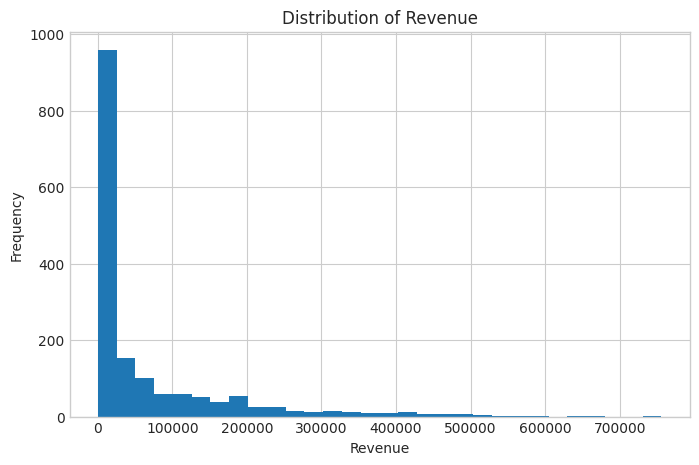

In [15]:
# Distribution of Revenue
plt.figure(figsize=(8,5))

plt.hist(df["revenue"], bins=30)

plt.title("Distribution of Revenue")

plt.xlabel("Revenue")

plt.ylabel("Frequency")

plt.show()

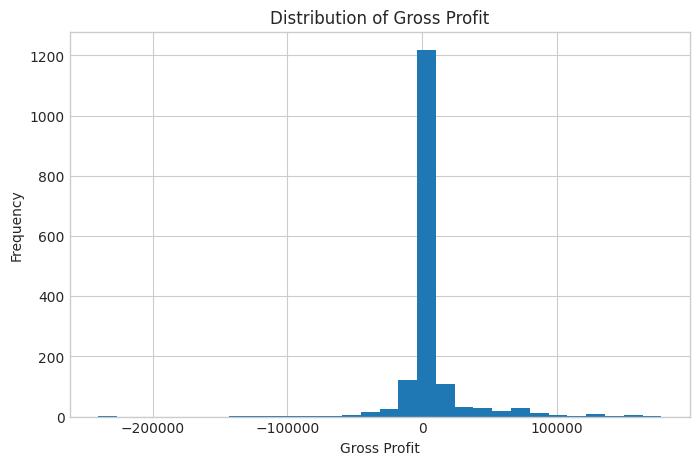

In [16]:
# Distribution of Gross Profit
plt.figure(figsize=(8,5))

plt.hist(df["gross_profit"], bins=30)

plt.title("Distribution of Gross Profit")

plt.xlabel("Gross Profit")

plt.ylabel("Frequency")

plt.show()

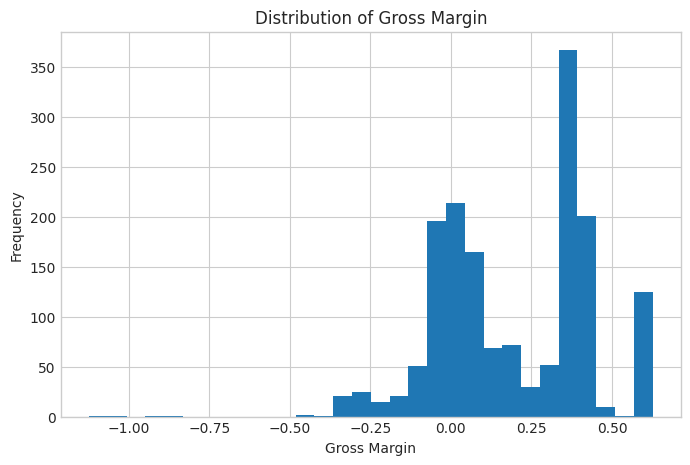

In [17]:
# Distribution of Gross Margin
plt.figure(figsize=(8,5))

plt.hist(df["gross_margin"], bins=30)

plt.title("Distribution of Gross Margin")

plt.xlabel("Gross Margin")

plt.ylabel("Frequency")

plt.show()

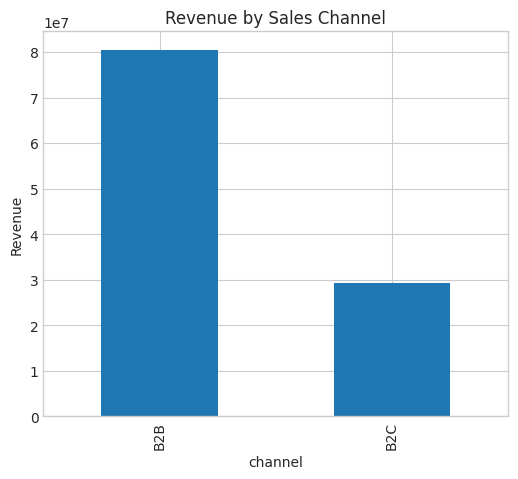

In [18]:
# Revenue of channels
channel = (
    df.groupby("channel")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(6,5))

channel.plot(kind="bar")

plt.title("Revenue by Sales Channel")

plt.ylabel("Revenue")

plt.show()

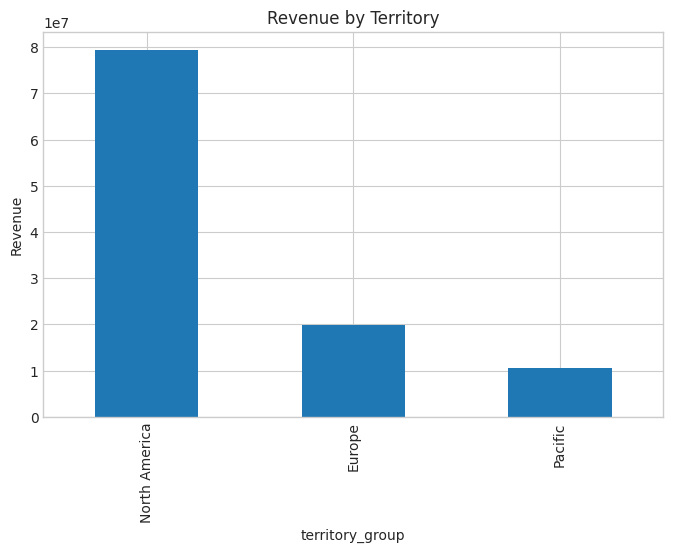

In [19]:
# Revenue of territory
territory = (
    df.groupby("territory_group")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

territory.plot(kind="bar")

plt.title("Revenue by Territory")

plt.ylabel("Revenue")

plt.show()

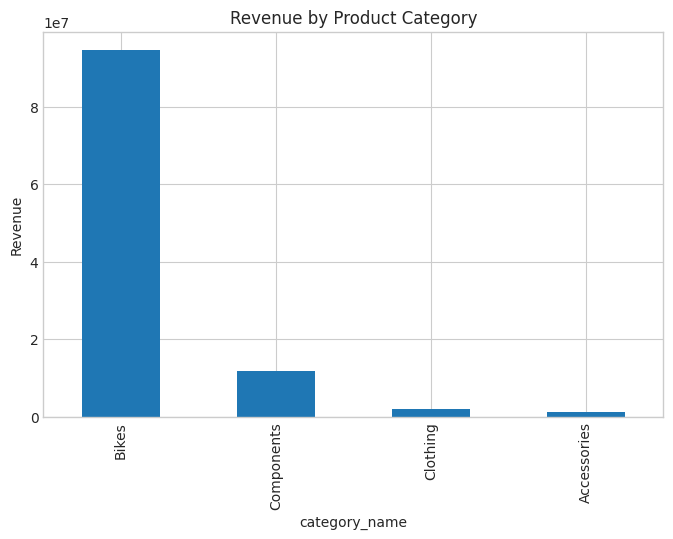

In [20]:
# Revenue of catogory
category = (
    df.groupby("category_name")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

category.plot(kind="bar")

plt.title("Revenue by Product Category")

plt.ylabel("Revenue")

plt.show()

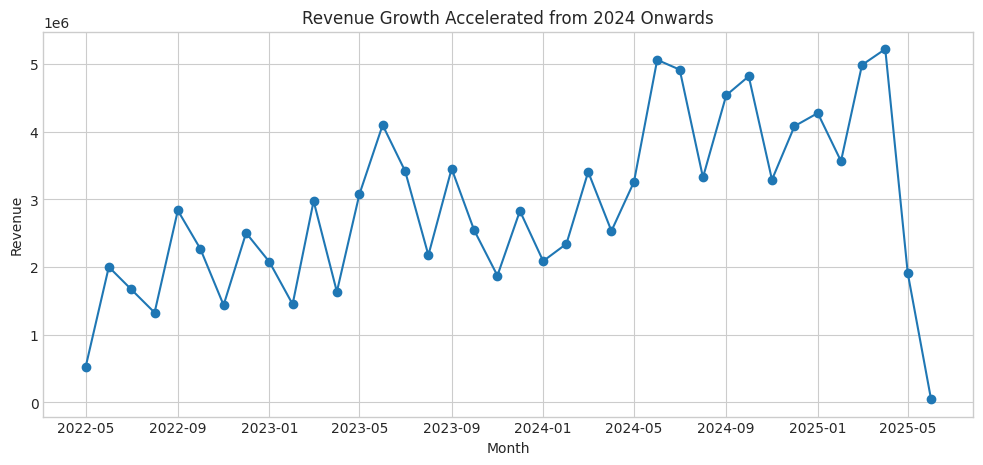

In [21]:
# Revenue of month
df["month_date"] = pd.to_datetime(
    df["month_key"].astype(str),
    format="%Y%m"
)

monthly = (
    df.groupby("month_date")["revenue"]
      .sum()
)

plt.figure(figsize=(12,5))

plt.plot(monthly.index, monthly.values, marker="o")

plt.title("Revenue Growth Accelerated from 2024 Onwards")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [22]:
# So sánh Fact vs Mart
audit = pd.DataFrame({
    "Metric": ["Revenue", "Orders", "Quantity"],
    "Fact": [
        fact_df.loc[0, "total_revenue"],
        fact_df.loc[0, "total_orders"],
        fact_df.loc[0, "total_quantity"]
    ],
    "Mart": [
        mart_df.loc[0, "total_revenue"],
        mart_df.loc[0, "total_orders"],
        mart_df.loc[0, "total_quantity"]
    ]
})

audit["Difference"] = audit["Mart"] - audit["Fact"]

audit["Status"] = audit["Difference"].apply(
    lambda x: "PASS" if abs(x) < 0.01 else "CHECK"
)

audit

,Metric,Fact,Mart,Difference,Status
0,Revenue,"109,846,381.40","109,846,381.40",0.00,PASS
1,Orders,"31,465.00","50,419.00","18,954.00",CHECK
2,Quantity,"274,914.00","274,914.00",0.00,PASS


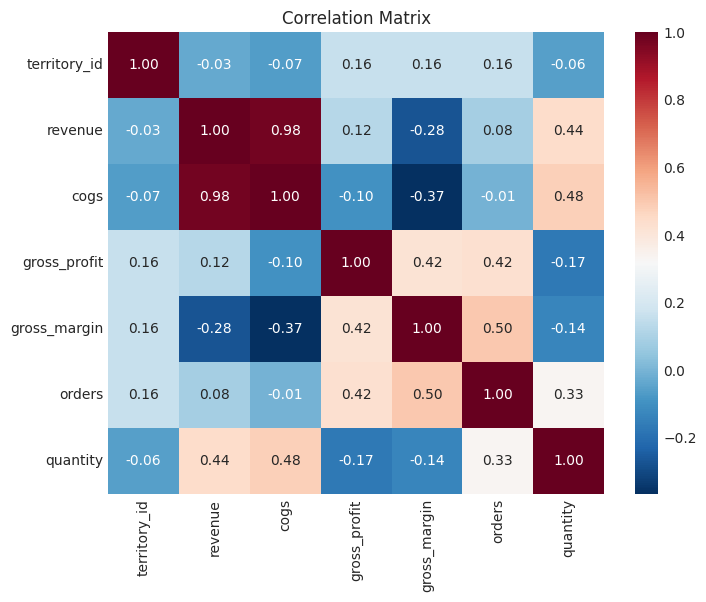

In [23]:
# Correlation Matrix
numeric = df.select_dtypes(include=["number"])

corr = numeric.corr()

corr

import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## 5. KPI

In [24]:
# KPI theo Tháng × Channel
kpi = (
    df.groupby(["month_key", "channel"], as_index=False)
      .agg(
          Revenue=("revenue", "sum"),
          Gross_Profit=("gross_profit", "sum"),
          Orders=("orders", "sum"),
          Quantity=("quantity", "sum")
      )
)

kpi.head()

,month_key,channel,Revenue,Gross_Profit,Orders,Quantity
0,202205,B2B,"489,328.58","-2,377.22",93,820
1,202205,B2C,"28,408.86","11,861.56",9,9
2,202206,B2B,"1,538,408.31","26,253.57",191,2053
3,202206,B2C,"462,870.65","185,037.46",142,142
4,202207,B2B,"1,165,897.08","25,891.13",152,1512


In [25]:
# Tính Gross Margin
kpi["Gross_Margin"] = (kpi["Gross_Profit"] / kpi["Revenue"]) * 100

# AVO
kpi["AOV"] = (kpi["Revenue"] /kpi["Orders"])

# Revenue growth
kpi = kpi.sort_values(["channel","month_key"])
kpi["Revenue_Growth_%"] = (kpi.groupby("channel")["Revenue"].pct_change()*100)

kpi = kpi.round(2)

kpi.head(15)


,month_key,channel,Revenue,Gross_Profit,Orders,Quantity,Gross_Margin,AOV,Revenue_Growth_%
0,202205,B2B,"489,328.58","-2,377.22",93,820,-0.49,"5,261.60",NaN
2,202206,B2B,"1,538,408.31","26,253.57",191,2053,1.71,"8,054.49",214.39
4,202207,B2B,"1,165,897.08","25,891.13",152,1512,2.22,"7,670.38",-24.21
6,202208,B2B,"844,721.00","-4,663.58",100,1242,-0.55,"8,447.21",-27.55
8,202209,B2B,"2,324,135.80","23,200.06",222,2963,1.00,"10,469.08",175.14
10,202210,B2B,"1,702,944.54","17,981.07",169,2245,1.06,"10,076.59",-26.73
12,202211,B2B,"713,116.69","-1,288.21",77,852,-0.18,"9,261.26",-58.12
14,202212,B2B,"1,900,788.93","16,066.95",167,2132,0.85,"11,381.97",166.55
16,202301,B2B,"1,455,280.41","19,596.80",138,1642,1.35,"10,545.51",-23.44
18,202302,B2B,"882,899.94","-5,445.50",99,1260,-0.62,"8,918.18",-39.33


## 6. Trend Analysis

In [26]:
# Chuyển month_key thành datetime

kpi["month_date"] = pd.to_datetime(
    kpi["month_key"].astype(str),
    format="%Y%m"
)

kpi.head()

,month_key,channel,Revenue,Gross_Profit,Orders,Quantity,Gross_Margin,AOV,Revenue_Growth_%,month_date
0,202205,B2B,"489,328.58","-2,377.22",93,820,-0.49,"5,261.60",NaN,2022-05-01
2,202206,B2B,"1,538,408.31","26,253.57",191,2053,1.71,"8,054.49",214.39,2022-06-01
4,202207,B2B,"1,165,897.08","25,891.13",152,1512,2.22,"7,670.38",-24.21,2022-07-01
6,202208,B2B,"844,721.00","-4,663.58",100,1242,-0.55,"8,447.21",-27.55,2022-08-01
8,202209,B2B,"2,324,135.80","23,200.06",222,2963,1.00,"10,469.08",175.14,2022-09-01


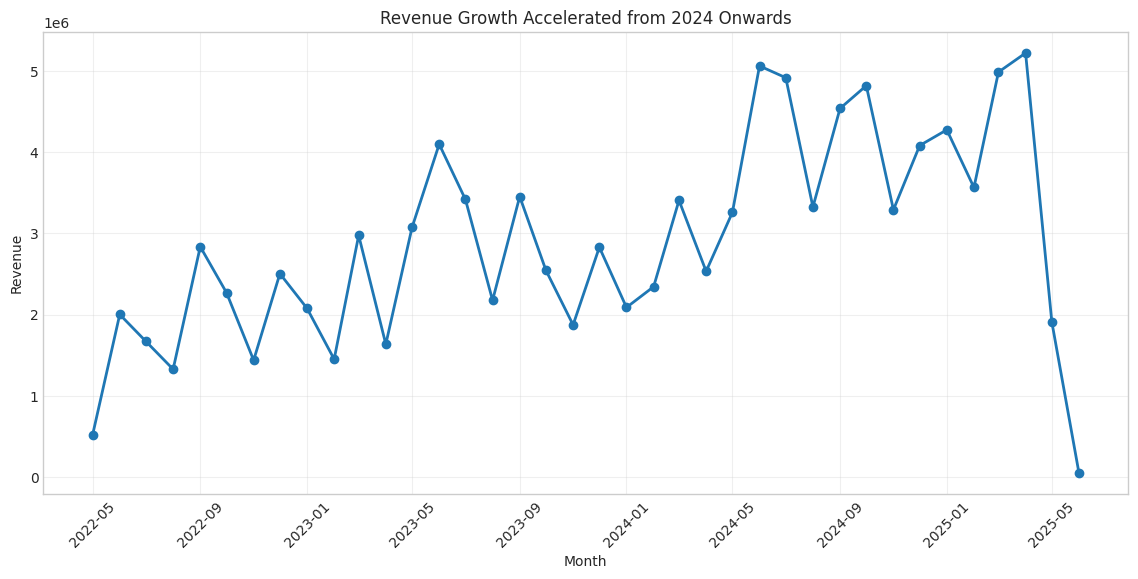

In [27]:
# Revenue trend
revenue_month = (
    kpi.groupby("month_date", as_index=False)
       .agg(Revenue=("Revenue", "sum"))
)

plt.figure(figsize=(14,6))

plt.plot(
    revenue_month["month_date"],
    revenue_month["Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Revenue Growth Accelerated from 2024 Onwards")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

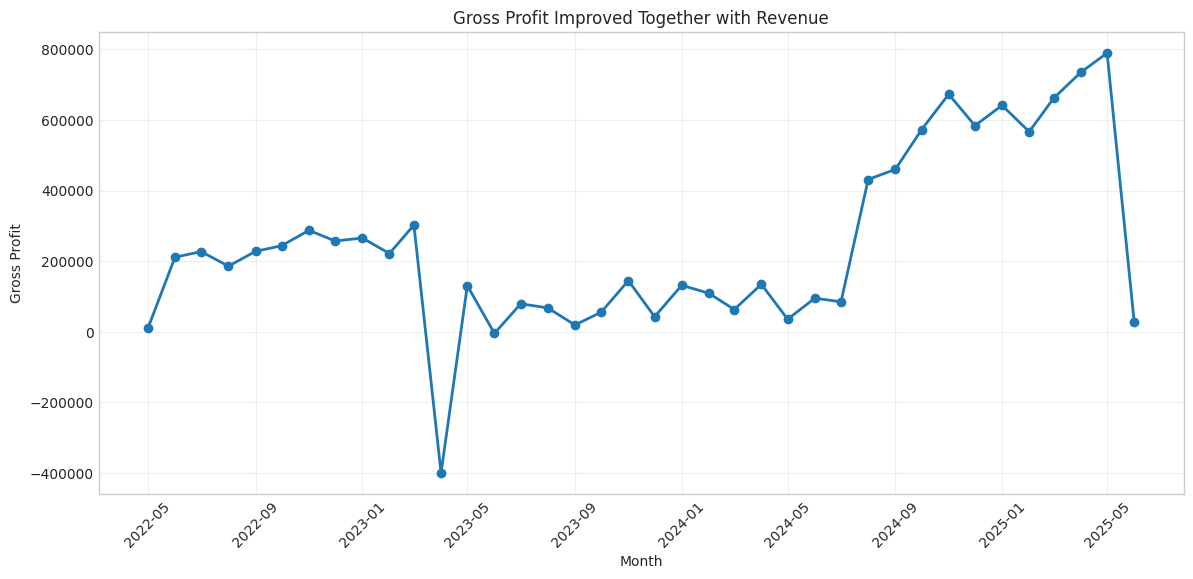

In [28]:
# Gross Profit trend
profit_month = (
    kpi.groupby("month_date", as_index=False)
       .agg(Gross_Profit=("Gross_Profit", "sum"))
)

plt.figure(figsize=(14,6))

plt.plot(
    profit_month["month_date"],
    profit_month["Gross_Profit"],
    marker="o",
    linewidth=2
)

plt.title("Gross Profit Improved Together with Revenue")

plt.xlabel("Month")

plt.ylabel("Gross Profit")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

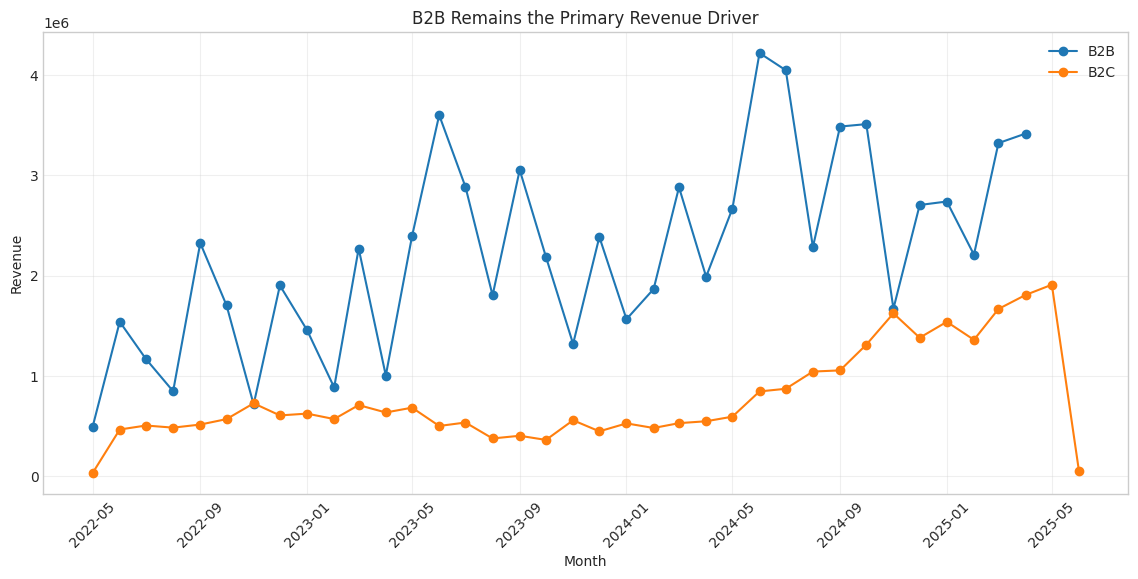

In [29]:
# Revenue of channel: giữ riêng B2B, B2C trước khi tổng hợp
plt.figure(figsize=(14,6))

for channel in kpi["channel"].unique():

    temp = kpi[kpi["channel"] == channel]

    plt.plot(
        temp["month_date"],
        temp["Revenue"],
        marker="o",
        label=channel
    )

plt.title("B2B Remains the Primary Revenue Driver")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.legend()

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()


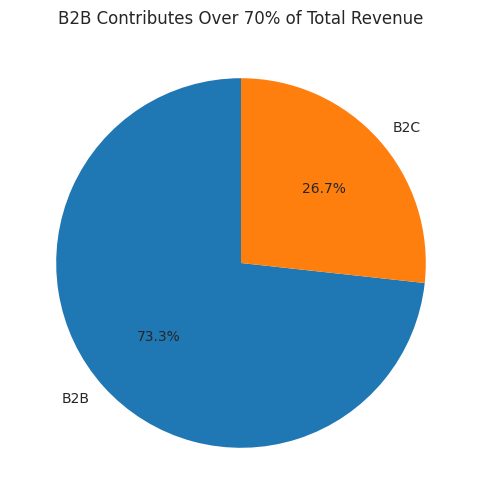

In [30]:
# Revenue share B2B vs B2C: không chỉ nhìn doanh thu tuyệt đối mà còn xem cơ cấu
channel_share = (
    kpi.groupby("channel")
       .agg(Revenue=("Revenue","sum"))
)

plt.figure(figsize=(6,6))

plt.pie(
    channel_share["Revenue"],
    labels=channel_share.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("B2B Contributes Over 70% of Total Revenue")

plt.show()

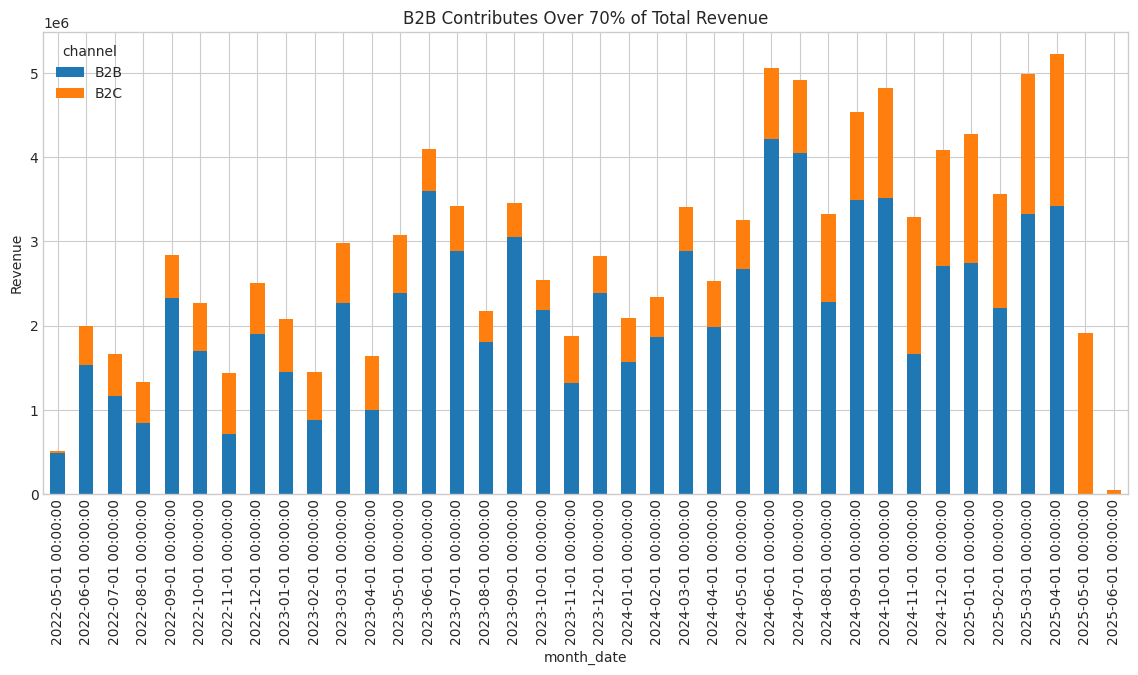

In [31]:
channel_month = (
    kpi.pivot(
        index="month_date",
        columns="channel",
        values="Revenue"
    )
)

channel_month.plot(
    kind="bar",
    stacked=True,
    figsize=(14,6)
)

plt.title("B2B Contributes Over 70% of Total Revenue")

plt.ylabel("Revenue")

plt.show()

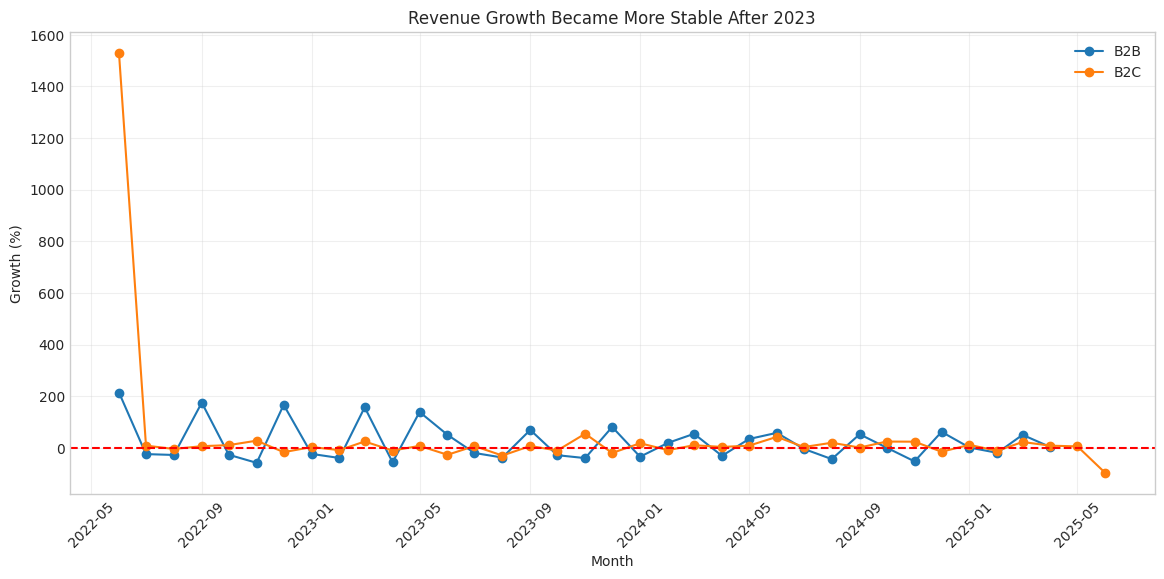

In [32]:
# Growth Rate
plt.figure(figsize=(14,6))

for channel in kpi["channel"].unique():

    temp = kpi[kpi["channel"] == channel]

    plt.plot(
        temp["month_date"],
        temp["Revenue_Growth_%"],
        marker="o",
        label=channel
    )

plt.title("Revenue Growth Became More Stable After 2023")

plt.xlabel("Month")

plt.ylabel("Growth (%)")

plt.axhline(0,color="red",linestyle="--")

plt.legend()

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

In [33]:
# Xác định cá giai đoạn nổi bật
# Tăng mạnh nhất
growth = (
    revenue_month.copy()
)

growth["Growth"] = growth["Revenue"].pct_change()*100

growth = growth.round(2)

growth.sort_values(
    "Growth",
    ascending=False
).head(5)

,month_date,Revenue,Growth
1,2022-06-01,"2,001,278.96",286.54
4,2022-09-01,"2,836,409.62",113.88
10,2023-03-01,"2,975,748.24",105.24
12,2023-05-01,"3,074,602.81",88.10
7,2022-12-01,"2,504,196.21",74.22


In [34]:
# Giảm mạnh nhất
growth.sort_values(
    "Growth",
    ascending=True
).head(5)

,month_date,Revenue,Growth
37,2025-06-01,"47,491.55",-97.51
36,2025-05-01,"1,908,059.49",-63.47
11,2023-04-01,"1,634,600.80",-45.07
6,2022-11-01,"1,437,342.53",-36.67
15,2023-08-01,"2,175,637.22",-36.35


In [35]:
# So sánh Fact vs Mart
audit = pd.DataFrame({
    "Metric": ["Revenue", "Orders", "Quantity"],
    "Fact": [
        fact_df.loc[0, "total_revenue"],
        fact_df.loc[0, "total_orders"],
        fact_df.loc[0, "total_quantity"]
    ],
    "Mart": [
        mart_df.loc[0, "total_revenue"],
        mart_df.loc[0, "total_orders"],
        mart_df.loc[0, "total_quantity"]
    ]
})

audit["Difference"] = audit["Mart"] - audit["Fact"]

audit["Status"] = audit["Difference"].apply(
    lambda x: "PASS" if abs(x) < 0.01 else "CHECK"
)

audit

,Metric,Fact,Mart,Difference,Status
0,Revenue,"109,846,381.40","109,846,381.40",0.00,PASS
1,Orders,"31,465.00","50,419.00","18,954.00",CHECK
2,Quantity,"274,914.00","274,914.00",0.00,PASS


### Nhận xét xu hướng doanh thu và lợi nhuận

Doanh thu của AdventureWorks có xu hướng tăng dần trong giai đoạn 2022–2025, đặc biệt từ giữa năm 2024 đến đầu năm 2025. Tuy nhiên, doanh thu biến động khá mạnh theo tháng, cho thấy hoạt động bán hàng có tính chu kỳ hoặc phụ thuộc vào các giai đoạn cao điểm.

Gross Profit cũng tăng rõ rệt từ nửa cuối năm 2024, cho thấy tăng trưởng doanh thu trong giai đoạn này có đi kèm với cải thiện lợi nhuận. Tuy nhiên, giai đoạn đầu năm 2023 xuất hiện một điểm giảm mạnh của Gross Profit, thậm chí âm, cần được kiểm tra thêm theo category hoặc territory để xác định nguyên nhân.

Phân tích theo kênh cho thấy B2B là kênh đóng góp chính vào doanh thu, chiếm khoảng 73.3% tổng doanh thu. B2C chiếm khoảng 26.7%, nhưng có xu hướng tăng đều hơn từ năm 2024 đến đầu năm 2025. Điều này cho thấy AdventureWorks vẫn phụ thuộc nhiều vào kênh B2B, nhưng B2C đang có dấu hiệu mở rộng.

Biểu đồ Revenue Growth Rate cho thấy các tháng đầu có mức tăng trưởng rất cao do nền doanh thu ban đầu thấp. Sau đó, tốc độ tăng trưởng dao động quanh mức 0%, phản ánh doanh thu đã ổn định hơn. Các tháng tăng trưởng mạnh gồm 2022-06, 2022-09, 2023-03 và 2023-05. Ngược lại, các tháng giảm mạnh gồm 2025-06, 2025-05, 2023-04, 2022-11 và 2023-08.

Đặc biệt, tháng 2025-06 có doanh thu giảm rất mạnh. Đây có thể là do dữ liệu tháng này chưa đầy đủ hoặc chỉ mới ghi nhận một phần tháng, vì doanh thu giảm xuống rất thấp so với các tháng trước. Do đó, khi trình bày dashboard, nên cân nhắc loại tháng 2025-06 khỏi phân tích xu hướng hoặc ghi chú rõ đây là kỳ dữ liệu chưa hoàn chỉnh.

Nhìn chung, AdventureWorks có xu hướng tăng trưởng tích cực, đặc biệt từ năm 2024. Tuy nhiên, tăng trưởng không ổn định giữa các tháng và phụ thuộc lớn vào kênh B2B. Các biến động bất thường ở đầu năm 2023 và tháng 2025-06 cần được phân tích sâu hơn ở các phần tiếp theo.

## 7. Contribution Analysis

7.1 Revenue Contribution by Territory

In [36]:
territory = (
    df.groupby("territory_group", as_index=False)
      .agg(
          Revenue=("revenue","sum"),
          Gross_Profit=("gross_profit","sum"),
          Orders=("orders","sum")
      )
)

territory = territory.sort_values(
    "Revenue",
    ascending=False
)

territory



,territory_group,Revenue,Gross_Profit,Orders
1,North America,"79,353,361.16","2,769,627.75",26692
0,Europe,"19,837,684.28","3,168,020.50",13742
2,Pacific,"10,655,335.96","3,434,255.38",9985


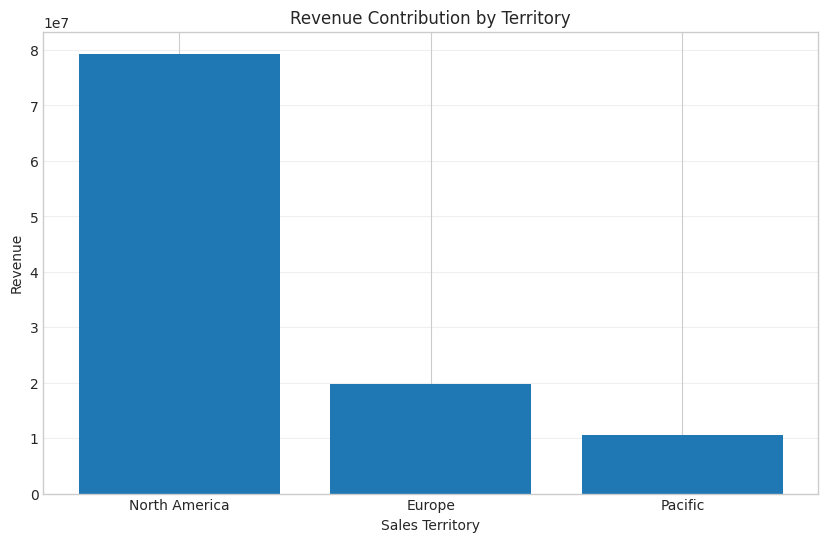

In [37]:
# Vẽ biểu đồ
plt.figure(figsize=(10,6))

plt.bar(
    territory["territory_group"],
    territory["Revenue"]
)

plt.title("Revenue Contribution by Territory")

plt.xlabel("Sales Territory")

plt.ylabel("Revenue")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [38]:
# Tính tỷ trọng
territory["Contribution_%"] = (
    territory["Revenue"] /
    territory["Revenue"].sum() * 100
).round(2)

territory

,territory_group,Revenue,Gross_Profit,Orders,Contribution_%
1,North America,"79,353,361.16","2,769,627.75",26692,72.24
0,Europe,"19,837,684.28","3,168,020.50",13742,18.06
2,Pacific,"10,655,335.96","3,434,255.38",9985,9.70


Nhận xét:

North America đóng góp doanh thu lớn nhất trong toàn bộ hệ thống. Các khu vực còn lại đóng góp thấp hơn đáng kể, cho thấy doanh thu của AdventureWorks đang tập trung ở một số thị trường chính.

7.2 Revenue Contribution by Channel

In [39]:
channel = (
    df.groupby("channel", as_index=False)
      .agg(
          Revenue=("revenue","sum"),
          Gross_Profit=("gross_profit","sum")
      )
)

channel["Contribution_%"] = (
    channel["Revenue"] /
    channel["Revenue"].sum()*100
).round(2)

channel

,channel,Revenue,Gross_Profit,Contribution_%
0,B2B,"80,487,704.18","-2,316,039.25",73.27
1,B2C,"29,358,677.22","11,687,942.88",26.73


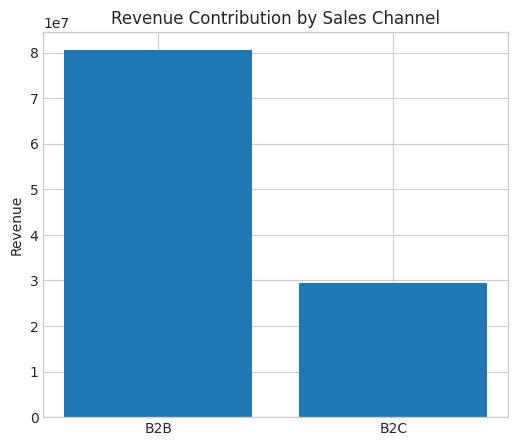

In [40]:
# Vẽ bar chart
plt.figure(figsize=(6,5))

plt.bar(
    channel["channel"],
    channel["Revenue"]
)

plt.title("Revenue Contribution by Sales Channel")

plt.ylabel("Revenue")

plt.show()

Nhận xét:

B2B chiếm phần lớn doanh thu của AdventureWorks, trong khi B2C đóng góp tỷ trọng nhỏ hơn nhưng có xu hướng tăng trưởng trong giai đoạn gần đây.

7.3 Revenue Contribution by Product Category

In [41]:
category = (
    df.groupby("category_name", as_index=False)
      .agg(
          Revenue=("revenue","sum"),
          Gross_Profit=("gross_profit","sum"),
          Orders=("orders","sum")
      )
)

category = category.sort_values(
    "Revenue",
    ascending=False
)

category["Contribution_%"] = (
    category["Revenue"] /
    category["Revenue"].sum()*100
).round(2)

category

,category_name,Revenue,Gross_Profit,Orders,Contribution_%
1,Bikes,"94,651,172.70","7,936,394.02",18368,86.17
3,Components,"11,802,593.29","490,233.18",2650,10.74
2,Clothing,"2,120,542.52","308,882.17",9877,1.93
0,Accessories,"1,272,072.88","636,394.26",19524,1.16


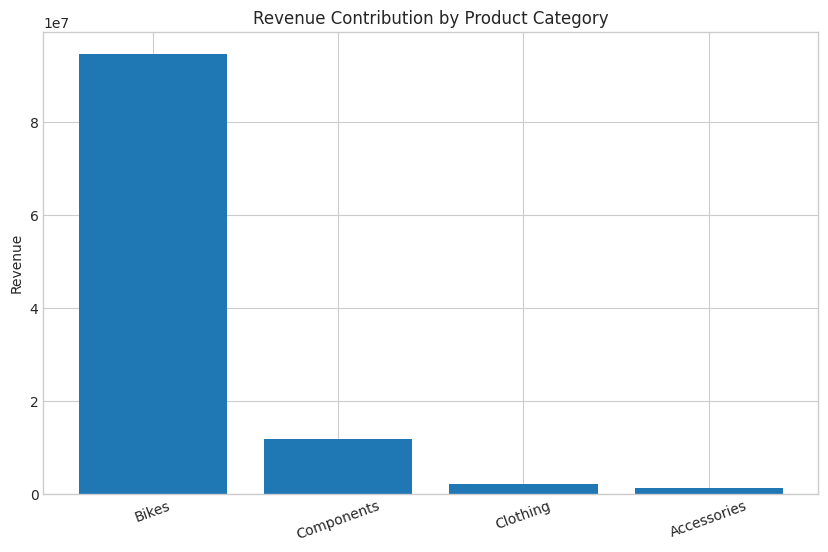

In [42]:
# Biểu đồ
plt.figure(figsize=(10,6))

plt.bar(
    category["category_name"],
    category["Revenue"]
)

plt.title("Revenue Contribution by Product Category")

plt.ylabel("Revenue")

plt.xticks(rotation=20)

plt.show()

Nhận xét:

Nhóm Bikes tạo ra doanh thu lớn nhất và là sản phẩm cốt lõi của AdventureWorks. Một số category khác có doanh thu thấp hơn và cần được đánh giá thêm về khả năng sinh lợi.


7.4 Top & Bottom Contributors

In [43]:
# Top and Bottom Categories
top_category = category.head(10)
bottom_category = category.tail(1)

display(top_category, bottom_category)

,category_name,Revenue,Gross_Profit,Orders,Contribution_%
1,Bikes,"94,651,172.70","7,936,394.02",18368,86.17
3,Components,"11,802,593.29","490,233.18",2650,10.74
2,Clothing,"2,120,542.52","308,882.17",9877,1.93
0,Accessories,"1,272,072.88","636,394.26",19524,1.16


,category_name,Revenue,Gross_Profit,Orders,Contribution_%
0,Accessories,"1,272,072.88","636,394.26",19524,1.16


In [44]:
# Bảng summary
def contribution_summary(df, dimension_col):
    temp = (
        df.groupby(dimension_col, as_index=False)
          .agg(Revenue=("revenue", "sum"))
    )

    temp["Contribution_%"] = (
        temp["Revenue"] / temp["Revenue"].sum() * 100
    )

    temp = temp.sort_values("Revenue", ascending=False)

    top = temp.iloc[0]
    bottom = temp.iloc[-1]

    return {
        "Dimension": dimension_col,
        "Top Contributor": top[dimension_col],
        "Top Contribution (%)": round(top["Contribution_%"], 2),
        "Bottom Contributor": bottom[dimension_col],
        "Bottom Contribution (%)": round(bottom["Contribution_%"], 2)
    }

summary_table["Dimension"] = summary_table["Dimension"].replace({
    "territory_group": "Territory",
    "channel": "Channel",
    "category_name": "Category"
})

summary_table

NameError: name 'summary_table' is not defined

In [ ]:
quota_columns = pd.read_sql("""
SELECT
    column_name,
    data_type
FROM information_schema.columns
WHERE table_schema='dwh'
AND table_name='fact_sales_quota'
ORDER BY ordinal_position;
""", engine)

quota_columns

In [ ]:
quota_sample = pd.read_sql("""
SELECT *
FROM dwh.fact_sales_quota
LIMIT 10;
""", engine)

quota_sample

7.5 Territory × Category Matrix

In [ ]:
matrix = pd.pivot_table(

    df,

    index="territory_group",

    columns="category_name",

    values="revenue",

    aggfunc="sum"

)

matrix

plt.figure(figsize=(10,6))

sns.heatmap(
    matrix,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Revenue Matrix: Territory × Category")

plt.show()

## 8. Đánh giá Quota

In [ ]:
# Phân tích Quota
quota = pd.read_sql("""
SELECT
    calendar_year,
    calendar_quarter,
    COUNT(employee_key) AS employees,
    SUM(sales_amount_quota) AS total_quota,
    AVG(sales_amount_quota) AS avg_quota
FROM dwh.fact_sales_quota
GROUP BY
    calendar_year,
    calendar_quarter
ORDER BY
    calendar_year,
    calendar_quarter;
""", engine)

quota

In [ ]:
# Vẽ xu hướng Quota
quota["period"] = (
    quota["calendar_year"].astype(str)
    + "-Q"
    + quota["calendar_quarter"].astype(str)
)

plt.figure(figsize=(10,5))

plt.plot(
    quota["period"],
    quota["total_quota"],
    marker="o",
    linewidth=2
)

plt.title("Quarterly Sales Quota")

plt.xlabel("Quarter")

plt.ylabel("Quota")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Top Employee Quota
employee_quota = pd.read_sql("""
SELECT
    employee_key,
    SUM(sales_amount_quota) AS quota
FROM dwh.fact_sales_quota
GROUP BY employee_key
ORDER BY quota DESC;
""", engine)

employee_quota.head(10)

In [ ]:
# Phân bố Quota
plt.figure(figsize=(8,5))

plt.hist(
    employee_quota["quota"],
    bins=15
)

plt.title("Distribution of Employee Sales Quota")

plt.xlabel("Quota")

plt.ylabel("Employees")

plt.show()

Nhận xét

Bảng FactSalesQuota lưu chỉ tiêu doanh số theo **Employee × Quarter**. Trong khi đó, Data Mart `mart_sales_kpi_monthly` được xây dựng theo **Month × Territory × Channel × Product Category** và không chứa `employee_key`.

Do khác grain dữ liệu, việc JOIN trực tiếp để tính Actual vs Quota sẽ không phản ánh chính xác kết quả kinh doanh. Vì vậy, trong Chương 1 chỉ trình bày xu hướng Sales Quota và phân bố chỉ tiêu theo nhân viên. Việc đánh giá mức độ hoàn thành chỉ tiêu (Quota Attainment) cần được thực hiện ở một Data Mart hoặc Fact có chứa cả doanh số thực tế và `employee_key`.